# When does simple win? Three tabular datasets at increasing difficulty

This notebook runs `stepzero` on three well-known classification datasets and lets the
headroom signal tell you what to do next.

| Dataset | Expected difficulty | Why |
|---------|-------------------|-----|
| Wine | Easy | Linearly separable classes |
| Titanic | Medium | Missing values, non-linear patterns |
| California Housing | Hard | Complex non-linear relationships |


In [1]:
import stepzero as sz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Dataset 1 — Wine (easy)

Three wine cultivars separated by chemical measurements. Logistic regression should nail this.

In [2]:
from sklearn.datasets import load_wine
X, y = load_wine(return_X_y=True, as_frame=True)
print(f"{len(X)} samples, {X.shape[1]} features, {len(set(y))} classes")
X.head(3)


178 samples, 13 features, 3 classes


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0


In [3]:
result = sz.classify(X, y)
print(result)
print()
print(result.headroom)


ClassifyResult(best='logistic', accuracy=0.983, headroom='Low')

[Low] Score of 0.98 with low variance (±0.014). The simple baseline is already performing well. Trying a gradient boosted tree (e.g., XGBoost or LightGBM) is unlikely to offer a meaningful improvement.


<Axes: title={'center': 'Wine: top features'}>

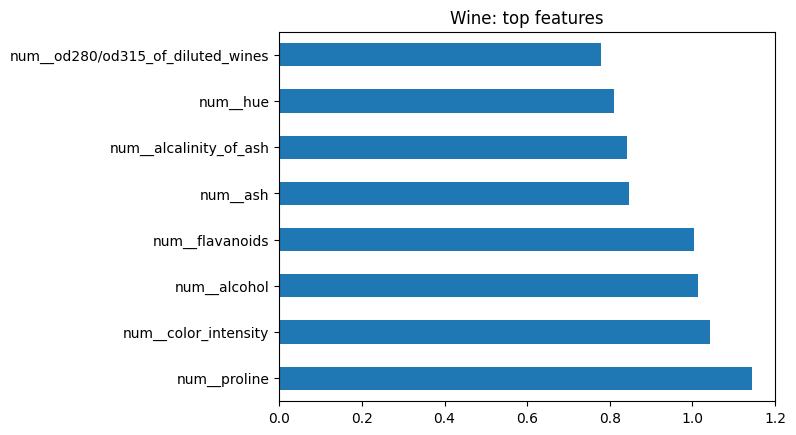

In [4]:
result.feature_importance.head(8).plot(kind="barh", title="Wine: top features")


## Dataset 2 — Titanic (medium)

The Kaggle classic. Simple models get ~80%; feature engineering and ensembles push toward 83–85%.

In [5]:
import seaborn as sns
titanic = sns.load_dataset("titanic")

# Basic feature prep — keep the columns a simple model can use
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
target = "survived"

df = titanic[features + [target]].dropna(subset=[target])
X = df[features]
y = df[target]
print(f"{len(X)} samples after dropping missing target")
X.head(3)


891 samples after dropping missing target


,pclass,sex,age,sibsp,parch,fare,embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S


In [6]:
result = sz.classify(X, y)
print(result)
print()
print(result.headroom)


ClassifyResult(best='tree', accuracy=0.813, headroom='Low')

[Low] Score of 0.81 with low variance (±0.015). The simple baseline is already performing well. Trying a gradient boosted tree (e.g., XGBoost or LightGBM) is unlikely to offer a meaningful improvement.


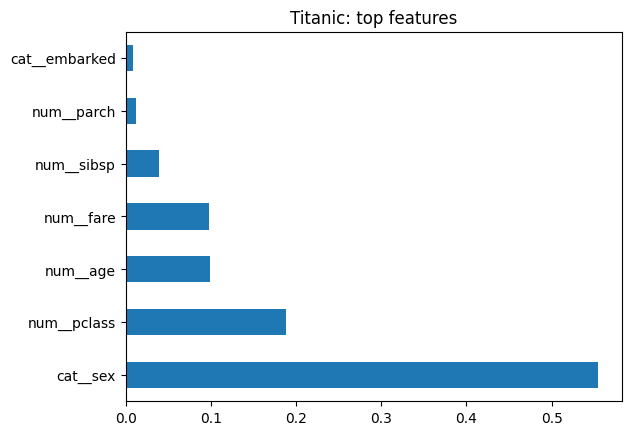

In [7]:
if result.feature_importance is not None:
    result.feature_importance.head(10).plot(kind="barh", title="Titanic: top features")


### What stepzero found
The headroom signal should be **Medium** — simple models plateau around 80% accuracy on Titanic.
Features like `title` (extracted from name), `family_size`, and `deck` are the usual gains.


## Dataset 3 — California Housing (hard)

Predict house prices from 8 features. Non-linear geography effects (latitude/longitude) mean
linear models leave significant RMSE on the table.

In [8]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target
print(f"{len(X)} samples, {X.shape[1]} features")
print(f"Target range: ${y.min()*100_000:.0f} – ${y.max()*100_000:.0f}")
X.head(3)


20640 samples, 8 features
Target range: $14999 – $500001


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24


In [9]:
result = sz.regress(X, y)
print(result)
print()
print(result.headroom)


RegressResult(best='tree', root mean squared error=0.719, headroom='Medium')

[Medium] Score of 0.7194 (±0.0136). Moderate headroom remains. Trying a gradient boosted tree (e.g., XGBoost or LightGBM) may yield a moderate improvement.


<Axes: title={'center': 'California Housing: feature importance'}>

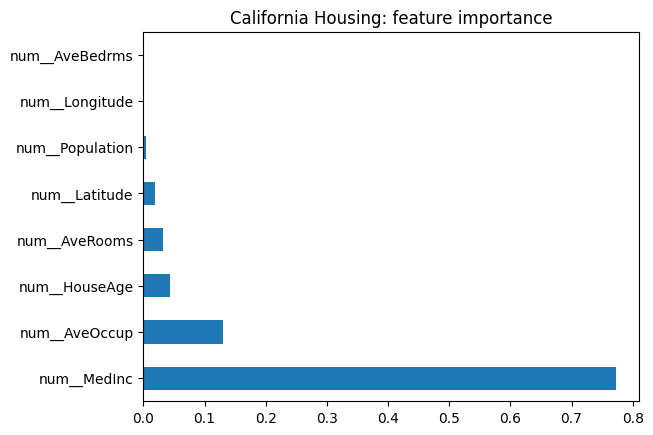

In [10]:
result.feature_importance.plot(kind="barh", title="California Housing: feature importance")


Text(0.5, 1.0, 'Residual distribution')

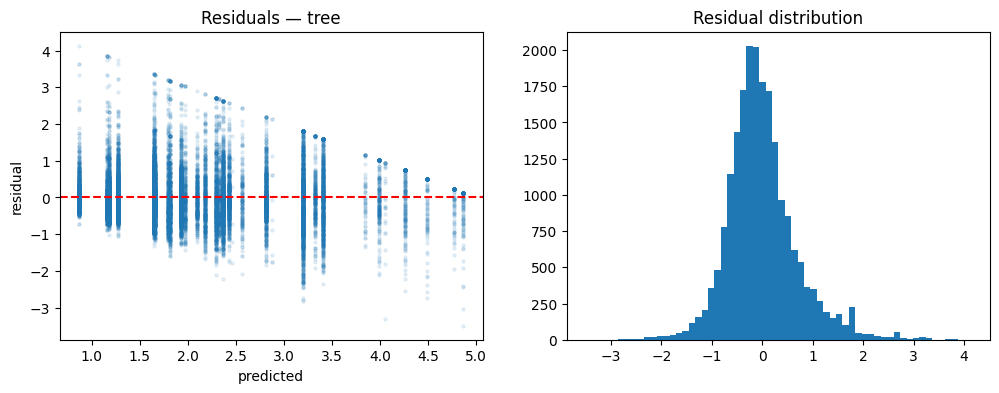

In [11]:
# Visualise residuals of the best model
y_pred = result.best_model.predict(X)
residuals = y - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred, residuals, alpha=0.1, s=5)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("predicted")
axes[0].set_ylabel("residual")
axes[0].set_title(f"Residuals — {result.best_model_name}")

axes[1].hist(residuals, bins=60, edgecolor="none")
axes[1].set_title("Residual distribution")


### Summary

| Dataset | Best model | Score | Headroom |
|---------|-----------|-------|----------|
| Wine | — | — | — |
| Titanic | — | — | — |
| California Housing | — | — | — |

Fill in from the outputs above. The progression from Low → Medium → High headroom shows
exactly when it's worth reaching for gradient boosting.
